## Table of contents

1. [**Inspecting Data**](#andmetesse_sissevaatamine)
2. [**Results Baselines**](#tulemused_baseline)

[end](#end)


### Conclusive evaluation results for the model

### Macro average metrics

> Note that the evaluation results are based on only the form label pairs, and thus do not take into account the POS tags.

| Model                        | Accuracy | Precision | Recall | F1-score |
| ---------------------------- | -------: | --------: | -----: | -------: |
| Most Frequent Class Baseline |   56.52% |    14.13% | 25.00% |   18.05% |
| Random Choice Baseline       |   24.58% |    24.90% | 24.12% |   19.70% |

Predictions outside the set of possible labels: **0/7886 (0.00%)**

### Weighted average metrics

> Note that the evaluation results are based on only the form label pairs, and thus do not take into account the POS tags.

| Model                        | Accuracy | Precision | Recall | F1-score |
| ---------------------------- | -------: | --------: | -----: | -------: |
| Most Frequent Class Baseline |   56.52% |    31.94% | 56.52% |   40.82% |
| Random Choice Baseline       |   24.58% |    42.82% | 24.58% |   29.66% |

Predictions outside the set of possible labels: **0/7886 (0.00%)**


### Imports


In [1]:
print("Test")

Test


In [2]:
import os
import evaluate
import re
import random
import math
import pandas as pd
import numpy as np
import estnltk, estnltk.converters, estnltk.taggers
import sklearn
import sklearn.metrics

from typing import Any, Tuple, Optional

import matplotlib.pyplot as plt
from matplotlib.ticker import FuncFormatter
import seaborn as sns

from tqdm import tqdm
from scripts.model.bert_morph_tagger import BertMorphTagger
from scripts.notebooks.NotebookFunctions import (
    _extract_prediction_from_layer,
    annotate_sentences_with_model,
    display_metrics_and_classification_report,
    plot_confusion_matrices,
    plot_true_vs_pred_by_inflection,
    display_examples,
    create_lenient_labels_and_split_counts_and_cases,
)

from scripts.config import (
    SEED,
    ROOT,
    DATA_DIR,
    ENC2017_ROOT,
    UD_ET_EDT_ROOT,
    HOMONYMS_ROOT,
    ENC2017_DIRS,
    UD_ET_EDT_DIRS,
    HOMONYMS_DIRS,
    OUTPUT_DIR,
    PLOTS_DIR,
    HOMONYMS_PLOTS_DIR,
    MODEL_DIR,
)

e:\Git_projects\EstNLTK\simpletransformers\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


<a id='andmetesse_sissevaatamine'></a>


### Inspecting Data


In [3]:
overall_df = pd.read_parquet(
    HOMONYMS_DIRS["processed"] / "homonyms_overall_updated_sentences.parquet"
)

In [4]:
overall_df.head()

,num,inflection_type,sentence,word,word_span,label,source
0,1,1,"Edinburghi agulite mehe Irvine Welshi ja Glasgow tööliskirjaniku, Bookeri võitja James Kelmani puhul võib tõlketõrke tekitada keelekasutus - inglise inglise keelele demonstratiivselt vastanduv proletaarne Scots.",võitja,"[74, 80]",[sg n],infl_type_01_1000_v1_project-1-at-2024-11-23-00-10-742338cd.json
1,1,1,"Normi-aktiveerimise teooria (Schwartz, 1970) on algselt mõeldud moraalse otsustamisprotsessi analüüsimiseks abistava käitumise näitel.",teooria,"[20, 27]",[sg n],infl_type_01_1000_v1_project-1-at-2024-11-23-00-10-742338cd.json
2,1,1,"""Ehk oleks mõttekas ka mõni selleteemaline hoiatav kampaania korraldada,"" lisab punase autoga preili.",kampaania,"[51, 60]",[sg n],infl_type_01_1000_v1_project-1-at-2024-11-23-00-10-742338cd.json
3,1,1,"""Minu otsus oli õige ning teeksin kõik sama moodi, kui saaksin uuesti teha,"" kommenteerib kolm aastat tagasi eriliste teenete eest Eesti passi saanud Primakov.",õige,"[16, 20]",[sg n],infl_type_01_1000_v1_project-1-at-2024-11-23-00-10-742338cd.json
4,1,1,"Itaalia president ütles Venemaa riigipea auks korraldatud suurejoonelisel banketil, et kahe riigi ühisavaldus Iraagi kohta oli kahe riigipea ""suur tarkuseavaldus"".",Itaalia,"[0, 7]",[sg g],infl_type_01_1000_v1_project-1-at-2024-11-23-00-10-742338cd.json


In [5]:
import numpy as np

# Convert list/array inflection types to tuples for consistent grouping
overall_df["label"] = overall_df["label"].apply(
    lambda x: tuple(x) if isinstance(x, (list, np.ndarray)) else x
)

display(
    overall_df.groupby(["inflection_type", "label"])
    .size()
    .reset_index()
    .sort_values(by="inflection_type")
)

,inflection_type,label,0
0,1,"(sg g,)",1232
1,1,"(sg n,)",764
2,16,"(sg g,)",1080
3,16,"(sg n,)",890
4,17,"(sg g,)",524
5,17,"(sg n,)",791
6,17,"(sg p,)",609
7,19,"(adt,)",94
8,19,"(sg g,)",1621
9,19,"(sg p,)",281


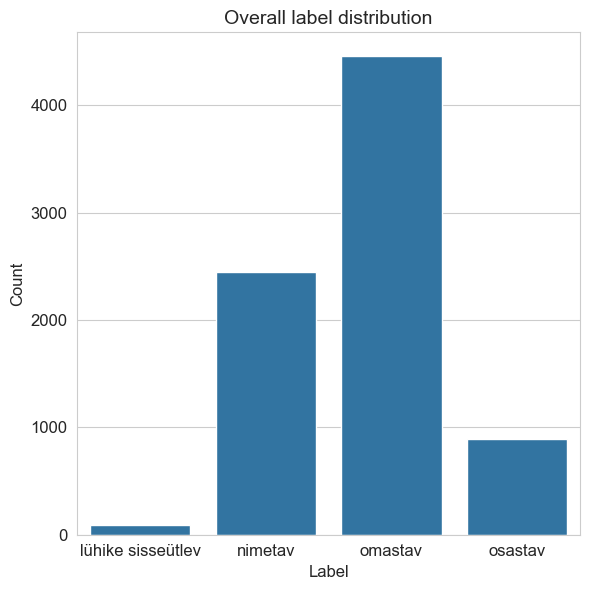

INFO:category.py:224: Using categorical units to plot a list of strings that are all parsable as floats or dates. If these strings should be plotted as numbers, cast to the appropriate data type before plotting.
INFO:category.py:224: Using categorical units to plot a list of strings that are all parsable as floats or dates. If these strings should be plotted as numbers, cast to the appropriate data type before plotting.


C:\Users\Admin\AppData\Local\Temp\ipykernel_32032\3500709682.py:38: UserWarning: The palette list has more values (10) than needed (4), which may not be intended.
  sns.countplot(


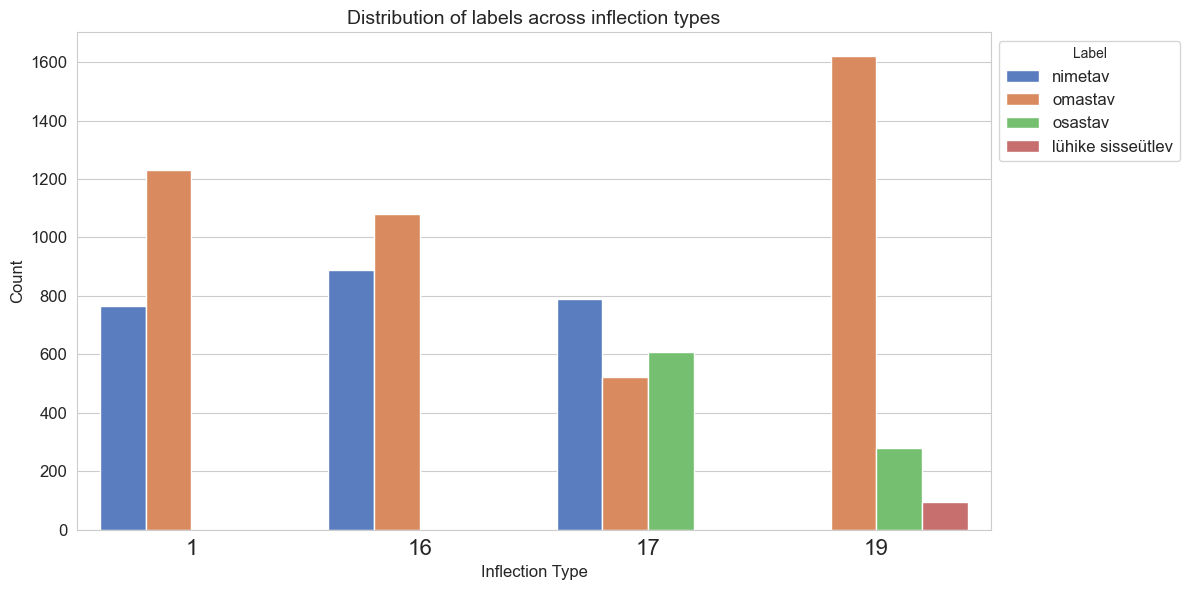

In [ ]:
overall_df["label_str"] = overall_df["label"].apply(lambda x: x[0])

# Rename the labels for better readability in plots
label_mapping = {
    "sg n": "nimetav",
    "sg g": "omastav",
    "sg p": "osastav",
    "adt": "lühike sisseütlev",
}
overall_df["label_str"] = (
    overall_df["label_str"].map(label_mapping).fillna(overall_df["label_str"])
)

# Plot label distribution
sns.set_style("whitegrid")
plt.figure(figsize=(6, 6))
sns.countplot(
    data=overall_df,
    x="label_str",
    order=sorted(overall_df["label_str"].dropna().unique()),
)
plt.title("Overall label distribution", fontsize=14)
plt.xlabel("Label", fontsize=12)
plt.ylabel("Count", fontsize=12)
plt.xticks(fontsize=12)
plt.yticks(fontsize=12)
plt.tight_layout()
plt.savefig(
    str(HOMONYMS_PLOTS_DIR / "overall_label_distribution.png"),
    dpi=300,
)
plt.show()

# Plot label distribution across inflection types
sns.set_style("whitegrid")
palette = sns.color_palette("muted")
plt.figure(figsize=(12, 6))
sns.countplot(
    data=overall_df,
    x="inflection_type",
    hue="label_str",
    palette=palette,
    order=sorted(overall_df["inflection_type"].dropna().unique()),
)
plt.title("Distribution of labels across inflection types", fontsize=14)
plt.xlabel("Inflection Type", fontsize=12)
plt.ylabel("Count", fontsize=12)
plt.xticks(fontsize=16)
plt.yticks(fontsize=12)
plt.legend(title="Label", bbox_to_anchor=(1, 1), loc="upper left", fontsize=12)
plt.tight_layout()
plt.savefig(
    str(HOMONYMS_PLOTS_DIR / "label_distribution_by_inflection_type.png"),
    dpi=300,
)
plt.show()

In [ ]:
overall_df.head()

,num,inflection_type,sentence,word,word_span,label,source
0,1,1,"Edinburghi agulite mehe Irvine Welshi ja Glasgow tööliskirjaniku, Bookeri võitja James Kelmani puhul võib tõlketõrke tekitada keelekasutus - inglise inglise keelele demonstratiivselt vastanduv proletaarne Scots.",võitja,"[74, 80]","(sg n,)",infl_type_01_1000_v1_project-1-at-2024-11-23-00-10-742338cd.json
1,1,1,"Normi-aktiveerimise teooria (Schwartz, 1970) on algselt mõeldud moraalse otsustamisprotsessi analüüsimiseks abistava käitumise näitel.",teooria,"[20, 27]","(sg n,)",infl_type_01_1000_v1_project-1-at-2024-11-23-00-10-742338cd.json
2,1,1,"""Ehk oleks mõttekas ka mõni selleteemaline hoiatav kampaania korraldada,"" lisab punase autoga preili.",kampaania,"[51, 60]","(sg n,)",infl_type_01_1000_v1_project-1-at-2024-11-23-00-10-742338cd.json
3,1,1,"""Minu otsus oli õige ning teeksin kõik sama moodi, kui saaksin uuesti teha,"" kommenteerib kolm aastat tagasi eriliste teenete eest Eesti passi saanud Primakov.",õige,"[16, 20]","(sg n,)",infl_type_01_1000_v1_project-1-at-2024-11-23-00-10-742338cd.json
4,1,1,"Itaalia president ütles Venemaa riigipea auks korraldatud suurejoonelisel banketil, et kahe riigi ühisavaldus Iraagi kohta oli kahe riigipea ""suur tarkuseavaldus"".",Itaalia,"[0, 7]","(sg g,)",infl_type_01_1000_v1_project-1-at-2024-11-23-00-10-742338cd.json


<a id='tulemused_baseline'></a>


### Baseline models (random choice and most frequent choice)


### Label distribution


In [6]:
overall_df = pd.read_parquet(
    HOMONYMS_DIRS["processed"] / "homonyms_overall_updated_sentences.parquet"
)

In [7]:
import numpy as np

# Convert list/array inflection types to tuples for consistent grouping
overall_df["label"] = overall_df["label"].apply(
    lambda x: x[0] if isinstance(x, (list, np.ndarray)) else x
)

In [8]:
overall_df.head()

,num,inflection_type,sentence,word,word_span,label,source
0,1,1,"Edinburghi agulite mehe Irvine Welshi ja Glasgow tööliskirjaniku, Bookeri võitja James Kelmani puhul võib tõlketõrke tekitada keelekasutus - inglise inglise keelele demonstratiivselt vastanduv proletaarne Scots.",võitja,"[74, 80]",sg n,infl_type_01_1000_v1_project-1-at-2024-11-23-00-10-742338cd.json
1,1,1,"Normi-aktiveerimise teooria (Schwartz, 1970) on algselt mõeldud moraalse otsustamisprotsessi analüüsimiseks abistava käitumise näitel.",teooria,"[20, 27]",sg n,infl_type_01_1000_v1_project-1-at-2024-11-23-00-10-742338cd.json
2,1,1,"""Ehk oleks mõttekas ka mõni selleteemaline hoiatav kampaania korraldada,"" lisab punase autoga preili.",kampaania,"[51, 60]",sg n,infl_type_01_1000_v1_project-1-at-2024-11-23-00-10-742338cd.json
3,1,1,"""Minu otsus oli õige ning teeksin kõik sama moodi, kui saaksin uuesti teha,"" kommenteerib kolm aastat tagasi eriliste teenete eest Eesti passi saanud Primakov.",õige,"[16, 20]",sg n,infl_type_01_1000_v1_project-1-at-2024-11-23-00-10-742338cd.json
4,1,1,"Itaalia president ütles Venemaa riigipea auks korraldatud suurejoonelisel banketil, et kahe riigi ühisavaldus Iraagi kohta oli kahe riigipea ""suur tarkuseavaldus"".",Itaalia,"[0, 7]",sg g,infl_type_01_1000_v1_project-1-at-2024-11-23-00-10-742338cd.json


In [9]:
# View label distribution in the dataset

# Count occurrences of each label in the entire dataset
label_distribution_overall = (
    overall_df.groupby("label").size().reset_index(name="count")
)

# Calculate percentages
label_distribution_overall["percentage"] = label_distribution_overall["count"].apply(
    lambda x: round(x / label_distribution_overall["count"].sum() * 100, 3)
)
print("=" * 5, "Overall Label Distribution", "=" * 5)
print(label_distribution_overall, "\n")


# View label distribution per inflection type and add percentage columns
print("=" * 5, "Label Distribution per Inflection Type", "=" * 5)

# Count occurrences of each label per inflection type
label_distribution = (
    overall_df.groupby(["inflection_type", "label"]).size().reset_index(name="count")
)

# Calculate percentages
label_distribution["percentage"] = label_distribution.groupby("inflection_type")[
    "count"
].transform(lambda x: round(x / x.sum() * 100, 3))

# Separate dataframes per inflection type
label_distribution_dfs = {}
for infl_type in label_distribution["inflection_type"].unique():
    label_distribution_dfs[infl_type] = label_distribution[
        label_distribution["inflection_type"] == infl_type
    ].reset_index(drop=True)
    print(f"Inflection Type {infl_type} Label Distribution:")
    print(label_distribution_dfs[infl_type])

===== Overall Label Distribution =====
  label  count  percentage
0   adt     94       1.192
1  sg g   4457      56.518
2  sg n   2445      31.004
3  sg p    890      11.286 

===== Label Distribution per Inflection Type =====
Inflection Type 1 Label Distribution:
   inflection_type label  count  percentage
0                1  sg g   1232      61.723
1                1  sg n    764      38.277
Inflection Type 16 Label Distribution:
   inflection_type label  count  percentage
0               16  sg g   1080      54.822
1               16  sg n    890      45.178
Inflection Type 17 Label Distribution:
   inflection_type label  count  percentage
0               17  sg g    524      27.235
1               17  sg n    791      41.112
2               17  sg p    609      31.653
Inflection Type 19 Label Distribution:
   inflection_type label  count  percentage
0               19   adt     94       4.709
1               19  sg g   1621      81.212
2               19  sg p    281      14.078


#### Overall homonym dataset


In [37]:
# Create a most frequent class baseline
most_frequent_baseline = sklearn.dummy.DummyClassifier(
    strategy="most_frequent", random_state=SEED
)
# Create a random choice baseline
random_choice_baseline = sklearn.dummy.DummyClassifier(
    strategy="uniform", random_state=SEED
)

In [38]:
# Fit and evaluate baselines
baseline_results = {}
for baseline, name in [
    (most_frequent_baseline, "Most Frequent Class Baseline"),
    (random_choice_baseline, "Random Choice Baseline"),
]:
    baseline.fit(
        overall_df["label"],
        overall_df["label"],
    )
    baseline_predictions = baseline.predict(
        overall_df["label"],
    )
    baseline_results[name] = {
        "pred_label": baseline_predictions,
        "inflection_type": overall_df["inflection_type"],
        "true_label": overall_df["label"],
    }

In [39]:
for model_name in [
    ("Most Frequent Class Baseline"),
    ("Random Choice Baseline"),
]:
    results_df = pd.DataFrame(baseline_results[model_name])
    results_df_split, results_df_filtered = (
        create_lenient_labels_and_split_counts_and_cases(
            results_df, "true_label", "pred_label"
        )
    )

    results_df_filtered_possibles = results_df_filtered[
        (results_df_filtered["true_case_lenient"] != "other")
        & (results_df_filtered["pred_case_lenient"] != "other")
    ]

    print(f"{model_name} results:")
    display_metrics_and_classification_report(
        results_df=results_df,
        pred_col="pred_label",
        true_col="true_label",
        show_metrics=True,
        show_classification_report=False,
    )
    print(f"\n{model_name} results (lenient):")
    display_metrics_and_classification_report(
        results_df=results_df_filtered,
        pred_col="pred_case_lenient",
        true_col="true_case_lenient",
        show_metrics=True,
        show_classification_report=False,
    )
    print(f"\n{model_name} results (lenient, excluding 'other'):")
    display_metrics_and_classification_report(
        results_df=results_df_filtered_possibles,
        pred_col="pred_case_lenient",
        true_col="true_case_lenient",
        show_metrics=True,
        show_classification_report=False,
    )

    # Count cases where "other" was predicted and the proportion of those out of all predictions
    other_pred_count = (results_df_filtered["pred_case_lenient"] == "other").sum()
    total_pred_count = len(results_df_filtered)
    print(
        f'\nNumber of "other" cases: {other_pred_count} out of {total_pred_count} ({other_pred_count / total_pred_count:.2%})'
    )

Most Frequent Class Baseline results:
Overall results
Accuracy:  56.52%
Precision: 14.13%
Recall:    25.00%
F1-score:  18.05%

Most Frequent Class Baseline results (lenient):
Overall results
Accuracy:  56.52%
Precision: 14.13%
Recall:    25.00%
F1-score:  18.05%

Most Frequent Class Baseline results (lenient, excluding 'other'):
Overall results
Accuracy:  56.52%
Precision: 14.13%
Recall:    25.00%
F1-score:  18.05%

Number of "other" cases: 0 out of 7886 (0.00%)
Random Choice Baseline results:
Overall results
Accuracy:  24.58%
Precision: 24.90%
Recall:    24.12%
F1-score:  19.70%

Random Choice Baseline results (lenient):
Overall results
Accuracy:  24.58%
Precision: 24.90%
Recall:    24.12%
F1-score:  19.70%

Random Choice Baseline results (lenient, excluding 'other'):
Overall results
Accuracy:  24.58%
Precision: 24.90%
Recall:    24.12%
F1-score:  19.70%

Number of "other" cases: 0 out of 7886 (0.00%)


Most Frequent Class Baseline results:


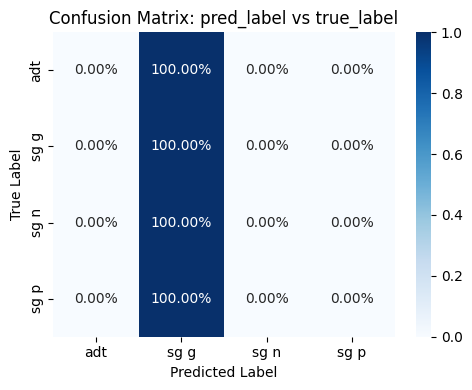

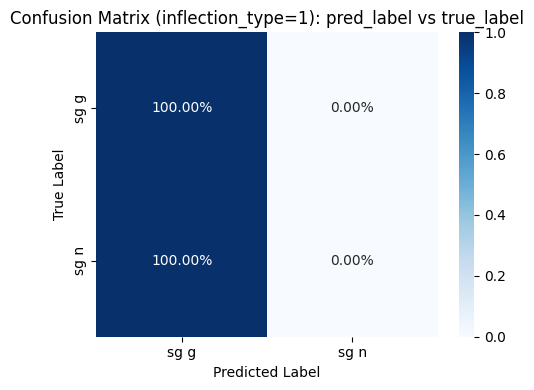

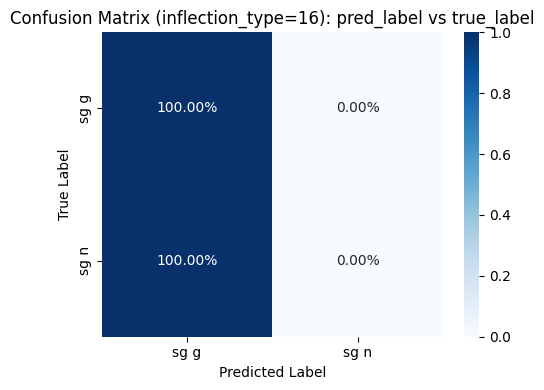

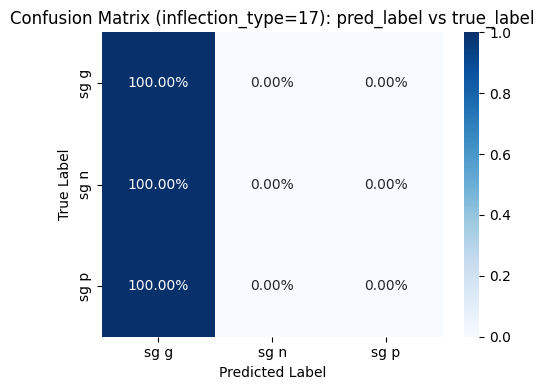

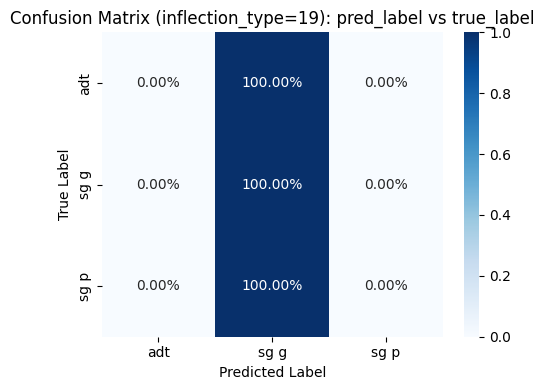

Random Choice Baseline results:


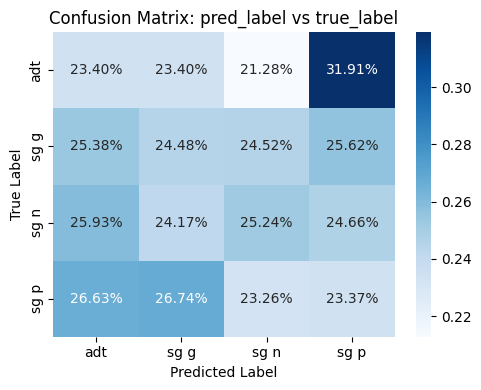

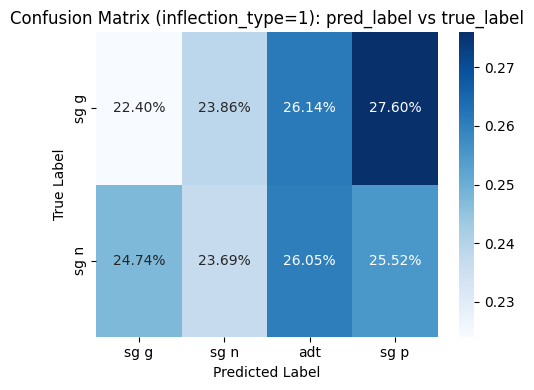

Confusion Matrix (inflection_type=1): pred_label vs true_label - Predicted-only labels (not present in true labels):
  predicted_only_label  count  share_pct  included_in_plot  threshold_pct
0                 sg p    535       26.8              True              0
1                  adt    521       26.1              True              0
Sum of true labels count: 1996


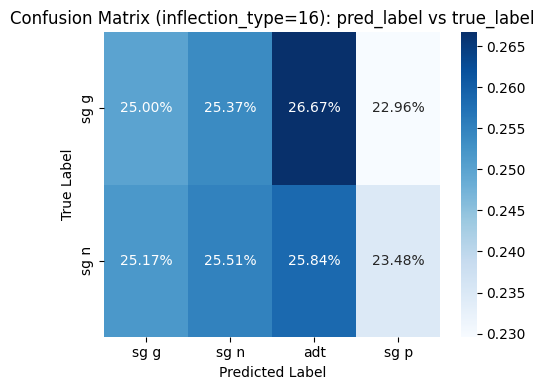

Confusion Matrix (inflection_type=16): pred_label vs true_label - Predicted-only labels (not present in true labels):
  predicted_only_label  count  share_pct  included_in_plot  threshold_pct
0                  adt    518      26.29              True              0
1                 sg p    457      23.20              True              0
Sum of true labels count: 1970


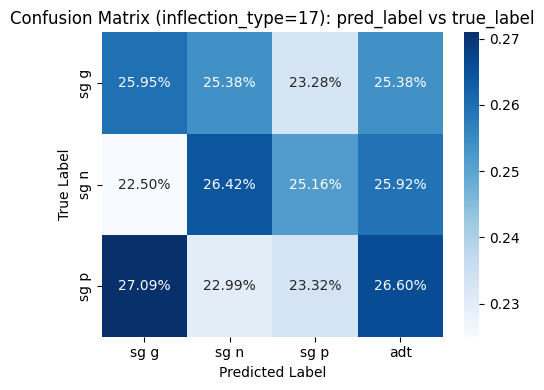

Confusion Matrix (inflection_type=17): pred_label vs true_label - Predicted-only labels (not present in true labels):
  predicted_only_label  count  share_pct  included_in_plot  threshold_pct
0                  adt    500      25.99              True              0
Sum of true labels count: 1924


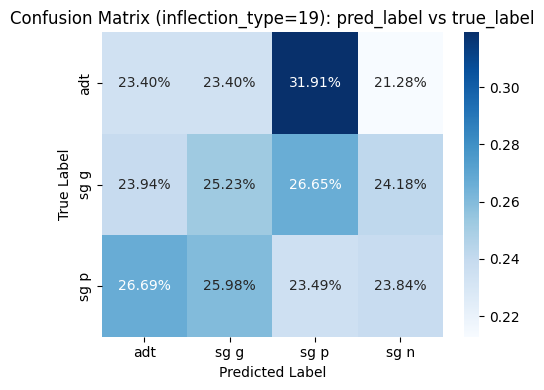

Confusion Matrix (inflection_type=19): pred_label vs true_label - Predicted-only labels (not present in true labels):
  predicted_only_label  count  share_pct  included_in_plot  threshold_pct
0                 sg n    479       24.0              True              0
Sum of true labels count: 1996


In [32]:
for name in [
    ("Most Frequent Class Baseline"),
    ("Random Choice Baseline"),
]:
    baseline_df = pd.DataFrame(baseline_results[name])
    print(f"{name} results:")
    plot_confusion_matrices(
        results_df=baseline_df,
        pred_col="pred_label",
        true_col="true_label",
        fig_size=(5, 4),
        save_path=str(HOMONYMS_PLOTS_DIR / "baseline" / f"{name}_CM.png"),
        significant_pred_threshold_pct=0,
    )
    plot_confusion_matrices(
        results_df=baseline_df,
        pred_col="pred_label",
        true_col="true_label",
        group_col="inflection_type",
        fig_size=(5, 4),
        save_path=str(HOMONYMS_PLOTS_DIR / "baseline" / f"{name}_CM_infl.png"),
        significant_pred_threshold_pct=0,
    )

#### Per inflection type homonym dataset


In [40]:
# Create a most frequent class baseline
most_frequent_baseline = sklearn.dummy.DummyClassifier(
    strategy="most_frequent", random_state=SEED
)
# Create a random choice baseline
random_choice_baseline = sklearn.dummy.DummyClassifier(
    strategy="uniform", random_state=SEED
)

In [41]:
# Fit and evaluate baselines
baseline_results = {}
for baseline, name in [
    (most_frequent_baseline, "Most Frequent Class Baseline"),
    (random_choice_baseline, "Random Choice Baseline"),
]:
    baseline_results[name] = {}
    for inflection_type in overall_df["inflection_type"].unique():
        inflection_data = overall_df[overall_df["inflection_type"] == inflection_type]
        baseline.fit(
            inflection_data["label"],
            inflection_data["label"],
        )
        baseline_predictions = baseline.predict(
            inflection_data["label"],
        )
        baseline_results[name][inflection_type] = {
            "pred_label": baseline_predictions,
            "inflection_type": inflection_data["inflection_type"],
            "true_label": inflection_data["label"],
        }

In [42]:
for model_name in [
    ("Most Frequent Class Baseline"),
    ("Random Choice Baseline"),
]:
    for inflection_type in overall_df["inflection_type"].unique():
        results_df = pd.DataFrame(baseline_results[model_name][inflection_type])
        print(f"{model_name} inflection type {inflection_type} results:")
        results_df_split, results_df_filtered = (
            create_lenient_labels_and_split_counts_and_cases(
                results_df, "true_label", "pred_label"
            )
        )

        results_df_filtered_possibles = results_df_filtered[
            (results_df_filtered["true_case_lenient"] != "other")
            & (results_df_filtered["pred_case_lenient"] != "other")
        ]

        print(f"{model_name} results:")
        display_metrics_and_classification_report(
            results_df=results_df,
            pred_col="pred_label",
            true_col="true_label",
            show_metrics=True,
            show_classification_report=False,
        )
        print(f"\n{model_name} results (lenient):")
        display_metrics_and_classification_report(
            results_df=results_df_filtered,
            pred_col="pred_case_lenient",
            true_col="true_case_lenient",
            show_metrics=True,
            show_classification_report=False,
        )
        print(f"\n{model_name} results (lenient, excluding 'other'):")
        display_metrics_and_classification_report(
            results_df=results_df_filtered_possibles,
            pred_col="pred_case_lenient",
            true_col="true_case_lenient",
            show_metrics=True,
            show_classification_report=False,
        )

        # Count cases where "other" was predicted and the proportion of those out of all predictions
        other_pred_count = (results_df_filtered["pred_case_lenient"] == "other").sum()
        total_pred_count = len(results_df_filtered)
        print(
            f'\nNumber of "other" cases: {other_pred_count} out of {total_pred_count} ({other_pred_count / total_pred_count:.2%})'
        )

Most Frequent Class Baseline inflection type 1 results:
Most Frequent Class Baseline results:
Overall results
Accuracy:  61.72%
Precision: 30.86%
Recall:    50.00%
F1-score:  38.17%

Most Frequent Class Baseline results (lenient):
Overall results
Accuracy:  61.72%
Precision: 30.86%
Recall:    50.00%
F1-score:  38.17%

Most Frequent Class Baseline results (lenient, excluding 'other'):
Overall results
Accuracy:  61.72%
Precision: 30.86%
Recall:    50.00%
F1-score:  38.17%

Number of "other" cases: 0 out of 1996 (0.00%)
Most Frequent Class Baseline inflection type 16 results:
Most Frequent Class Baseline results:
Overall results
Accuracy:  54.82%
Precision: 27.41%
Recall:    50.00%
F1-score:  35.41%

Most Frequent Class Baseline results (lenient):
Overall results
Accuracy:  54.82%
Precision: 27.41%
Recall:    50.00%
F1-score:  35.41%

Most Frequent Class Baseline results (lenient, excluding 'other'):
Overall results
Accuracy:  54.82%
Precision: 27.41%
Recall:    50.00%
F1-score:  35.41%



Most Frequent Class Baseline results:


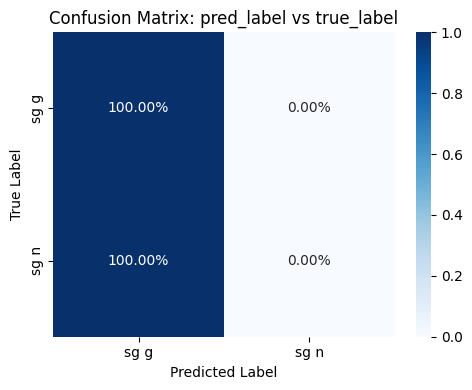

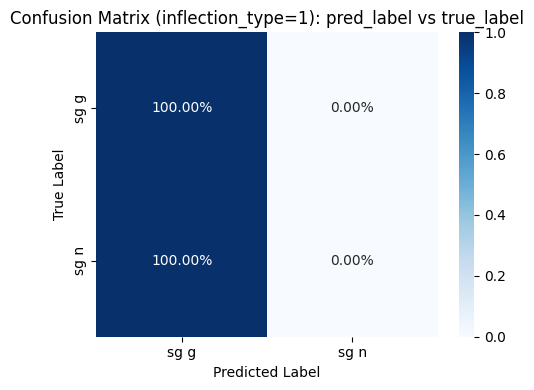

Most Frequent Class Baseline results:


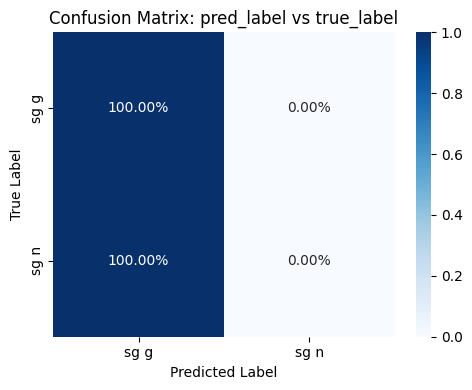

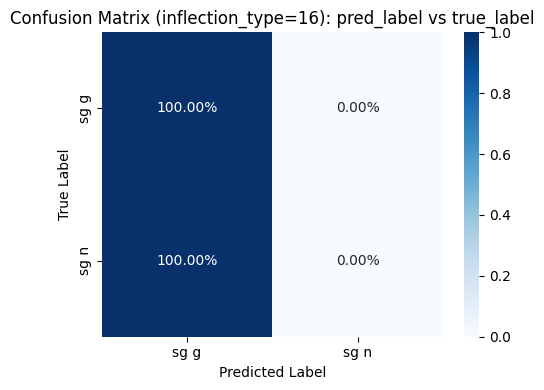

Most Frequent Class Baseline results:


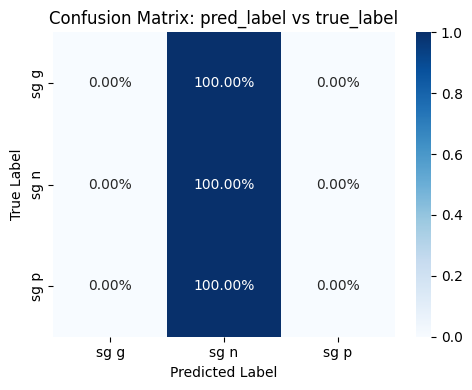

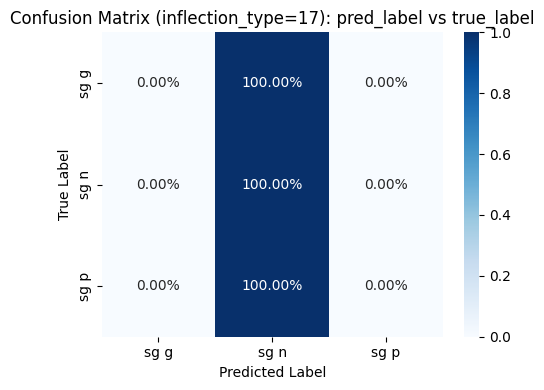

Most Frequent Class Baseline results:


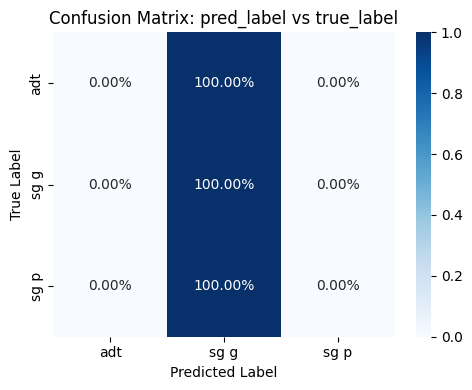

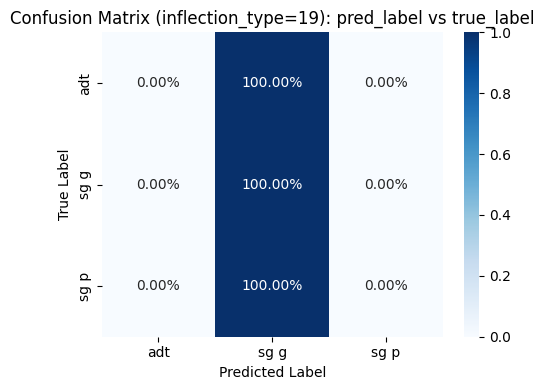

Random Choice Baseline results:


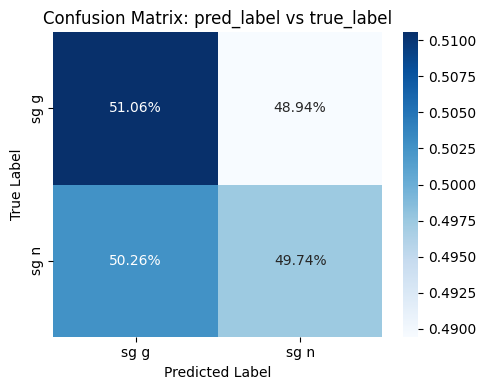

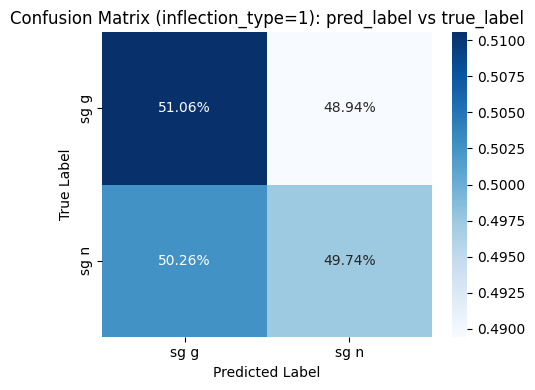

Random Choice Baseline results:


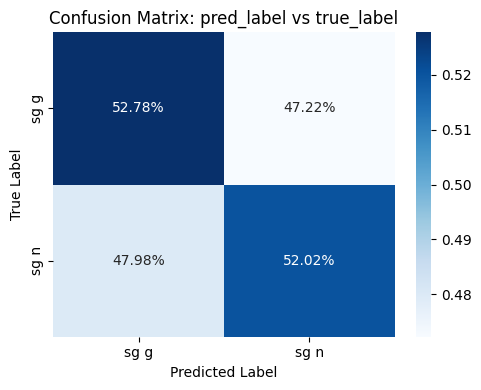

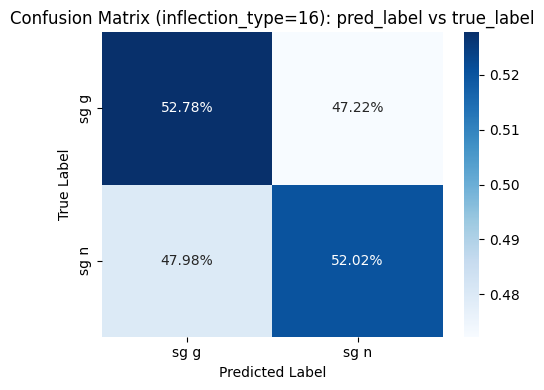

Random Choice Baseline results:


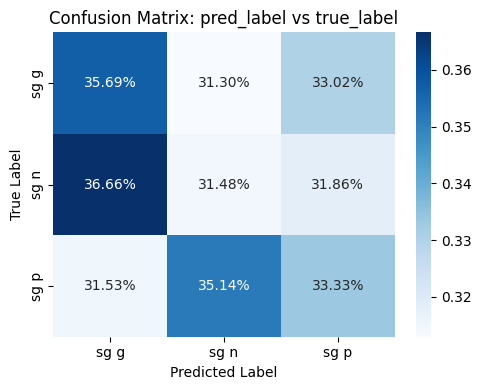

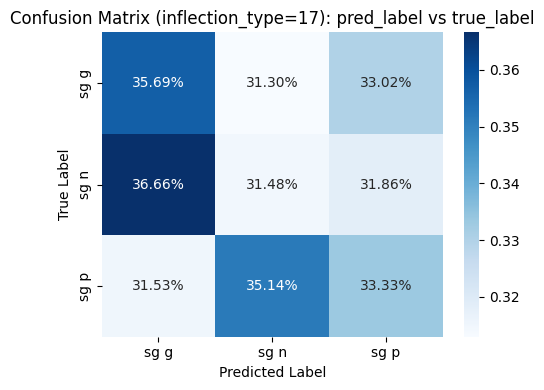

Random Choice Baseline results:


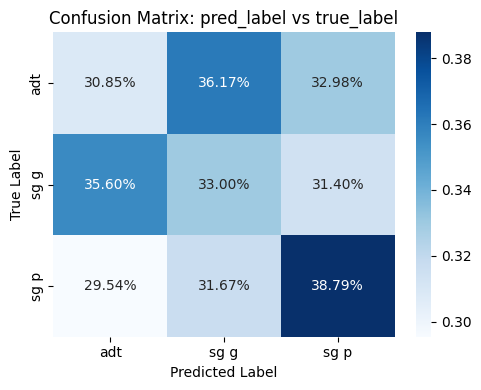

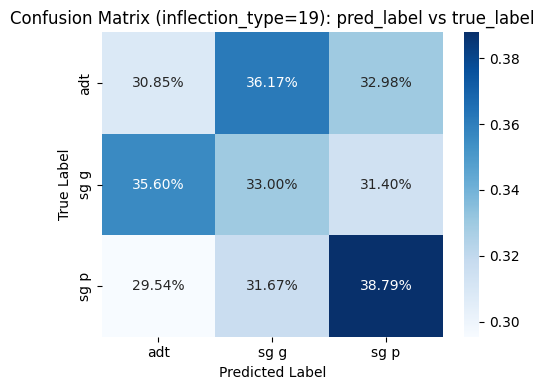

In [36]:
for name in [
    ("Most Frequent Class Baseline"),
    ("Random Choice Baseline"),
]:
    for inflection_type in overall_df["inflection_type"].unique():
        baseline_df = pd.DataFrame(baseline_results[name][inflection_type])
        print(f"{name} results:")
        plot_confusion_matrices(
            results_df=baseline_df,
            pred_col="pred_label",
            true_col="true_label",
            fig_size=(5, 4),
            save_path=str(HOMONYMS_PLOTS_DIR / "baseline" / f"{name}_infl_CM.png"),
            significant_pred_threshold_pct=0,
        )
        plot_confusion_matrices(
            results_df=baseline_df,
            pred_col="pred_label",
            true_col="true_label",
            group_col="inflection_type",
            fig_size=(5, 4),
            save_path=str(HOMONYMS_PLOTS_DIR / "baseline" / f"{name}_infl_CM_infl.png"),
            significant_pred_threshold_pct=0,
        )